In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import seaborn as sns 

In [6]:
df = pd.read_excel("focus_products.xlsx")
df
df.columns = df.columns.str.strip()
df.columns

Index(['product-name', 'Pareto % Products', 'Sum of absolute-quantity-gms',
       'Sum of Net_Price'],
      dtype='object')

In [11]:
features = ['Sum of absolute-quantity-gms','Sum of Net_Price']

In [14]:
df_clean = df.dropna(subset=features).copy()
df_clean

,product-name,Pareto % Products,Sum of absolute-quantity-gms,Sum of Net_Price
0,FZYEZY Freeze Dried Apple Slices for Kids and ...,0.3962,140,1000
1,FZYEZY Freeze Dried Black Jamun Fruit for Kids...,0.1293,1740,6120
2,FZYEZY Freeze Dried Custard Apple Fruit Powder...,0.6846,600,2320
3,FzyEzy Freeze Dried Fruit Powder for Gourmet,0.7511,300,2874
4,FzyEzy Freeze Dried Gajar Ka Halwa,0.7909,600,1250
5,FzyEzy Freeze Dried Ginger Vegetable Powder fo...,0.7713,850,2550
6,FZYEZY Freeze Dried Mango Fruit Powder for Kid...,0.3424,1750,4284
7,FZYEZY Freeze Dried Pink Guava Powder for Kids...,0.5905,950,3188
8,FzyEzy Freeze-Dried Apple Powder - 100% Natura...,0.4977,900,4171
9,FzyEzy Freeze-Dried Celery Powder - 100% Natur...,0.2415,1362,6150


In [16]:
x_scaled = StandardScaler().fit_transform(df_clean[features])
x_scaled

array([[-0.68376794, -1.50094221],
       [ 0.2395442 ,  1.81148197],
       [-0.4183157 , -0.64695785],
       [-0.59143673, -0.2885432 ],
       [-0.4183157 , -1.33920274],
       [-0.27404818, -0.49815754],
       [ 0.2453149 ,  0.62366736],
       [-0.21634117, -0.08539844],
       [-0.24519467,  0.55056113],
       [ 0.0214117 ,  1.83089071],
       [-0.37676665, -0.78928857],
       [-0.32021379, -0.72459279],
       [-0.33175519, -0.78928857],
       [-0.50256793, -0.10545413],
       [-0.34906729, -0.6922449 ],
       [-0.56258322, -1.24215907],
       [-0.52218832, -1.37155064],
       [-0.36060869, -0.72459279],
       [-0.3894622 , -0.65601526],
       [-0.24057811, -0.33641808],
       [-0.24519467,  0.56544116],
       [-0.4183157 , -0.98337593],
       [-0.30751824,  0.51950715],
       [ 1.31289455,  1.46988823],
       [-0.24057811,  0.37652947],
       [ 3.56346788,  2.51019645],
       [-0.4183157 , -0.43993134],
       [-0.4471692 , -0.32736067],
       [ 0.54539134,

In [ ]:
silhouette_scores = {} 
K_range = range(2,11)
for K in K_range :
    k_means = KMeans(n_clusters=K, random_state=42)
    k_means.fit(x_scaled)
score = silhouette_score(x_scaled,k_means.labels_)
silhouette_scores[K] = score 
score



c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

0.47087221453877276

In [20]:
optimal_k = max(silhouette_scores,key=silhouette_scores.get)
optimal_k

10

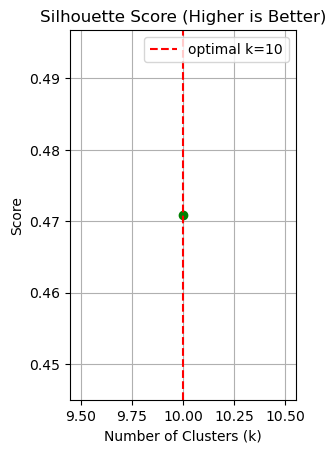

In [21]:
plt.subplot(1, 2, 2)
plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), marker='o', color='green', linestyle='--')
plt.title('Silhouette Score (Higher is Better)')
plt.xlabel('Number of Clusters (k)')
plt.axvline(x=optimal_k,color="red",linestyle="--",label=f"optimal k={optimal_k}")
plt.ylabel('Score')
plt.legend()
plt.grid(True)

In [24]:
final_cluster = KMeans(n_clusters=optimal_k,random_state=42)
df_clean["cluster"] = final_cluster.fit_predict(x_scaled)
df_clean

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,product-name,Pareto % Products,Sum of absolute-quantity-gms,Sum of Net_Price,cluster
0,FZYEZY Freeze Dried Apple Slices for Kids and ...,0.3962,140,1000,6
1,FZYEZY Freeze Dried Black Jamun Fruit for Kids...,0.1293,1740,6120,4
2,FZYEZY Freeze Dried Custard Apple Fruit Powder...,0.6846,600,2320,0
3,FzyEzy Freeze Dried Fruit Powder for Gourmet,0.7511,300,2874,7
4,FzyEzy Freeze Dried Gajar Ka Halwa,0.7909,600,1250,6
5,FzyEzy Freeze Dried Ginger Vegetable Powder fo...,0.7713,850,2550,0
6,FZYEZY Freeze Dried Mango Fruit Powder for Kid...,0.3424,1750,4284,2
7,FZYEZY Freeze Dried Pink Guava Powder for Kids...,0.5905,950,3188,7
8,FzyEzy Freeze-Dried Apple Powder - 100% Natura...,0.4977,900,4171,8
9,FzyEzy Freeze-Dried Celery Powder - 100% Natur...,0.2415,1362,6150,4


In [25]:
df_clean.to_excel("amazon_data_clustering.xlsx",index=False)